#[Assignment 10] Feature Engineering; PCA vs Perceptron Transformer!

🚀 *Let’s dive in and make this an awesome learning experience!*

## ✨ Step 0: Importing Base Modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## ✨ Step 1: Load the Dataset

In this assignment, you will work with a dataset called **Fashion-MNIST**. This dataset contains images (60000 for training and 10000 for testing) labeled with 10 different classes:

* 0 - T-shirt/top
* 1 - Trouser
* 2 - Pullover
* 3 - Dress
* 4 - Coat
* 5 - Sandal
* 6 - Shirt
* 7 - Sneaker
* 8 - Bag
* 9 - Ankle boot"

💡 You can read more about the dataset here: https://github.com/zalandoresearch/fashion-mnist

In [54]:
from keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

Let's see the size of the arrays

In [55]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

Let's look at some of the sample images 🖼️

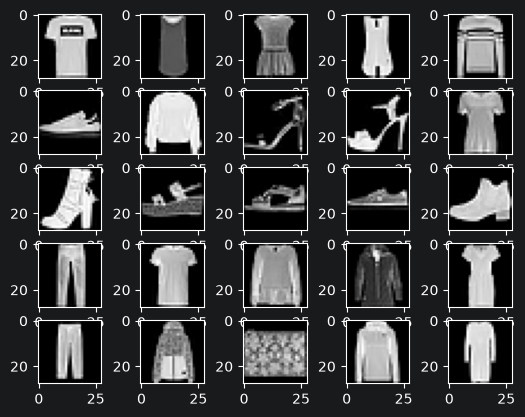

In [56]:
import matplotlib.pyplot as plt
for i in range(1,26):
  plt.subplot(5,5,i)
  plt.imshow(X_train[i],cmap='gray')

##✨ Step 2: Reshape the dataset arrays

1.   **Reshape** the training and testing image arrays so that each image becomes a single row (record), and each pixel becomes a column (feature).
For example, if you have 10,000 images of size 28×28, the reshaped data should have a shape of (10000, 784).
2.   **Invert** the pixel intensities by applying the transformation below — that is, take the absolute difference between 255 and the original value for each pixel::

$$
\text{new value} = |255 - \text{original value}|
$$

💡*This transfomation flips the brightness levels similar to what we did in the lectures — darker pixels become lighter and vice versa.*

In [57]:
X_train_Reshaped=255-X_train.reshape((X_train.shape[0],-1))
X_test_Reshaped=255-X_test.reshape((X_test.shape[0],-1))


If you completed the code above correctly, the following command should show images with white background

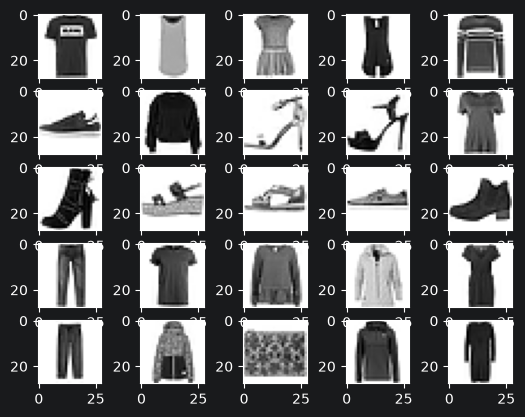

In [58]:
for i in range(1,26):
  plt.subplot(5,5,i)
  plt.imshow(X_train_Reshaped[i].reshape(28,28),cmap='gray')

##✨ Step 3: Building a Pipeline — PCA + Logistic Regression

In this section, we’ll create a pipeline that first applies **PCA (Principal Component Analysis)** to transform and reduce feature dimensions 🧭, and then uses **Logistic Regression**🎯 to classify the data based on these transformed features.

### 🪜 Step 3.1: Applying PCA

▶️ Run the code below to find the first 30 major principle components in the dataset.

⚡ Run the following code exactly as it is — do not change anything!

In [76]:
from sklearn.decomposition import PCA
pca = PCA(n_components=30)
X_train_pca = pca.fit_transform(X_train_Reshaped)
X_test_pca = pca.transform(X_test_Reshaped)

🎯 Find the smallest number of components, `n_components`, that together capture **at least 70% of the total variance** in the training data.

*   You’ll do this by trying different values for `n_components` in the next code block and printing the corresponding `total_variance_n_components` until it reaches (or slightly exceeds) 70%.

💡 Hint: Start with smaller numbers and gradually increase — this helps you see how quickly variance accumulates!

In [83]:
# NOTE - You could make this easier by using PCA(n_components=0.70) and have sklearn find it automatically.
# Tried manually 5...10.
n_components = 9

🎯 Task: Write code to calculate the total variance explained by the selected `n_components`, and store the result in a variable named `total_variance_n_components`.


In [84]:
total_variance_n_components=np.sum(pca.explained_variance_ratio_[0:n_components])

In [85]:
print(total_variance_n_components)

0.7067655994598667


### 🪜 Step 3.2 Logistic regression

⚙️ Task: Adjust the parameters of LogisticRegression until no warnings appear during training!

💡  The `max_iter` value must be **less than or equal to 100**, so try experimenting with other parameters to achieve convergence without increasing iterations.


In [106]:
from sklearn.linear_model import LogisticRegression
# Per rules, cannot change max_iter.

LGR=LogisticRegression(max_iter=100, C=0.5, solver='sag', verbose=1) #fill the model parameters inside the parenthesis.


#Do not change the line below
LGR.fit(X_train_pca[:,0:n_components],y_train)

Epoch 1, change: 1
Epoch 2, change: 0.26128986
Epoch 3, change: 0.19072799
Epoch 4, change: 0.26724896
Epoch 5, change: 0.18139308
Epoch 6, change: 0.10163764
Epoch 7, change: 0.059335569
Epoch 8, change: 0.038951715
Epoch 9, change: 0.048639146
Epoch 10, change: 0.021807873
Epoch 11, change: 0.016750966
Epoch 12, change: 0.015441059
Epoch 13, change: 0.0099611652
Epoch 14, change: 0.0061249593
Epoch 15, change: 0.0053513571
Epoch 16, change: 0.0038990049
Epoch 17, change: 0.003459583
Epoch 18, change: 0.0034731466
Epoch 19, change: 0.0019987508
Epoch 20, change: 0.0012755768
Epoch 21, change: 0.0013219034
Epoch 22, change: 0.00092634427
Epoch 23, change: 0.00068733044
Epoch 24, change: 0.00047082317
Epoch 25, change: 0.00044072907
Epoch 26, change: 0.00020954127
Epoch 27, change: 0.00028789504
Epoch 28, change: 0.00026976468
Epoch 29, change: 0.00017835702
Epoch 30, change: 0.00013869094
Epoch 31, change: 0.00011427948
convergence after 32 epochs took 1 seconds


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'sag'
,"verbose verbose: int, default=0For the liblinear and lbfgs solvers set verbose to any positivenumber for verbosity.",1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Ne

▶️ Run the following code to view the classification report and confusion matrix for both the training and testing sets.

⚡ Run the following code exactly as it is — do not change anything!

In [102]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay,f1_score

print("---------Training subset---------\n",classification_report(y_train,LGR.predict(X_train_pca[:,0:n_components])))
print("---------Testing subset----------\n",classification_report(y_test,LGR.predict(X_test_pca[:,0:n_components])))

---------Training subset---------
               precision    recall  f1-score   support

           0       0.71      0.80      0.75      6000
           1       0.94      0.91      0.93      6000
           2       0.55      0.58      0.56      6000
           3       0.75      0.83      0.79      6000
           4       0.61      0.58      0.60      6000
           5       0.80      0.81      0.81      6000
           6       0.49      0.37      0.42      6000
           7       0.79      0.80      0.79      6000
           8       0.92      0.91      0.91      6000
           9       0.87      0.89      0.88      6000

    accuracy                           0.75     60000
   macro avg       0.74      0.75      0.74     60000
weighted avg       0.74      0.75      0.74     60000

---------Testing subset----------
               precision    recall  f1-score   support

           0       0.70      0.78      0.74      1000
           1       0.94      0.90      0.92      1000
        

Text(0.5, 1.0, 'Test Confusion Matrix')

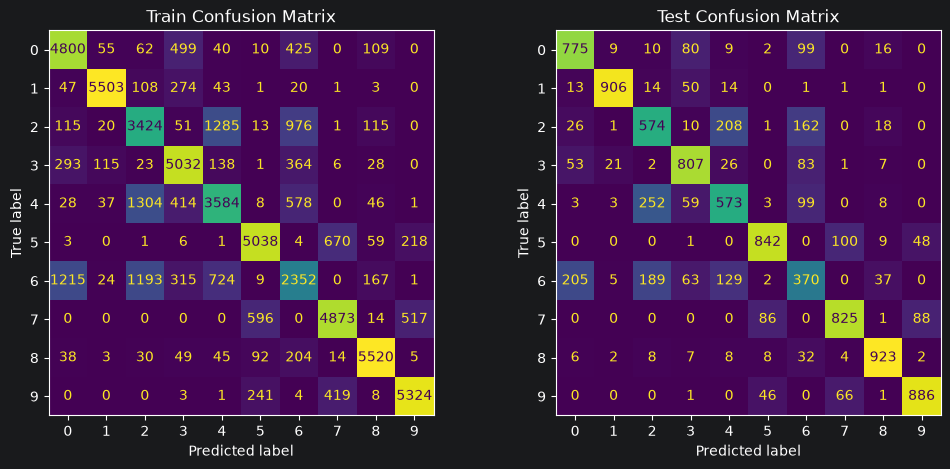

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 1️⃣ Train Confusion Matrix ---
plt.sca(axes[0])
ConfusionMatrixDisplay(confusion_matrix(y_train,LGR.predict(X_train_pca[:,0:n_components]))).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train Confusion Matrix")

# --- 2️⃣ Test Confusion Matrix ---
plt.sca(axes[1])
ConfusionMatrixDisplay(confusion_matrix(y_test,LGR.predict(X_test_pca[:,0:n_components]))).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test Confusion Matrix")

Based on the above values, which class has the largest number of misclassified records?

In [69]:
# ASSUME - Comparing test set.
cm = confusion_matrix(y_test,LGR.predict(X_test_pca[:,0:n_components]))
wc_lgr_n = 0
Worstclass_LGR = -1
for ij in range(len(cm)):
    for jk in range(len(cm)):
        if ij == jk:
            # Correct classes don't count, and these better be high, LOL.
            continue
        if cm[ij,jk] > wc_lgr_n:
            wc_lgr_n = cm[ij,jk]
            Worstclass_LGR = ij

Worstclass_LGR

4

##✨ Step 4: Multi-Layer Perceptron (MLP)

**Read Carefully:**

In the previous section, we applied a linear classifier — LogisticRegression — on a reduced feature set obtained using PCA and achieved an accuracy of around 70%.

**Pipeline Recap:**

*   Original Features (784 features) ➡️ PCA ➡️ Transformed Features
(n_components) ➡️ Logistic Regression

Now, let’s take it a step further! 🎯

In this section, we’ll build a **Multi-Layer Perceptron (MLP)** network that uses a hidden layer with **the same number of neurons** as `n_components`.
This hidden layer will learn **a non-linear transformation** of the data — similar to PCA, but more powerful — and we’ll use the final layer for classification.

**New Pipeline:**

*   Original Features (784 features) ➡️ Hidden Layer Perceptrons ➡️ Transformed Features (n_components) ➡️ Output Layer Perceptrons

💡 *In short: instead of letting PCA **linearly** transform the data, we’re letting the MLP learn its own transformation — and then classify based on it!*

### 🪜 Step 4.1 Normalizing the features

Never forget that you need to normalize the features before training **Neural Networks**. Complete the following code and normalize the features using `StandardScaler`

In [70]:
from sklearn.preprocessing import StandardScaler
#Complete the code below
scl = StandardScaler()
X_train_Reshaped_normalized=scl.fit_transform(X_train_Reshaped)
X_test_Reshaped_Normalized=scl.transform(X_test_Reshaped)



### 🪜 Step 4.2 Training the MLP

⚡ Run the following code exactly as it is — do not change anything!

⏳ This code may take up to 3 minutes to run, so please be patient.

In [32]:
from sklearn.neural_network import MLPClassifier
MLP=MLPClassifier(hidden_layer_sizes=(n_components,),max_iter=300)
MLP.fit(X_train_Reshaped_normalized,y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(9,)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


▶️ Run the following code to view the classification report and confusion matrix for both the training and testing sets.

This demonstrates the performance of a two-layer perceptron —
the first layer transforms the 784 original features into `n_components` features, and the second layer performs the classification.

In [33]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay

print("---------Training subset---------\n",classification_report(y_train,MLP.predict(X_train_Reshaped_normalized)))
print("---------Testing subset----------\n",classification_report(y_test,MLP.predict(X_test_Reshaped_Normalized)))

---------Training subset---------
               precision    recall  f1-score   support

           0       0.82      0.88      0.85      6000
           1       0.99      0.98      0.99      6000
           2       0.82      0.81      0.81      6000
           3       0.92      0.89      0.90      6000
           4       0.81      0.83      0.82      6000
           5       0.99      0.97      0.98      6000
           6       0.73      0.70      0.72      6000
           7       0.97      0.96      0.96      6000
           8       0.99      0.98      0.99      6000
           9       0.95      0.99      0.97      6000

    accuracy                           0.90     60000
   macro avg       0.90      0.90      0.90     60000
weighted avg       0.90      0.90      0.90     60000

---------Testing subset----------
               precision    recall  f1-score   support

           0       0.78      0.82      0.80      1000
           1       0.97      0.96      0.96      1000
        

Text(0.5, 1.0, 'Test Confusion Matrix')

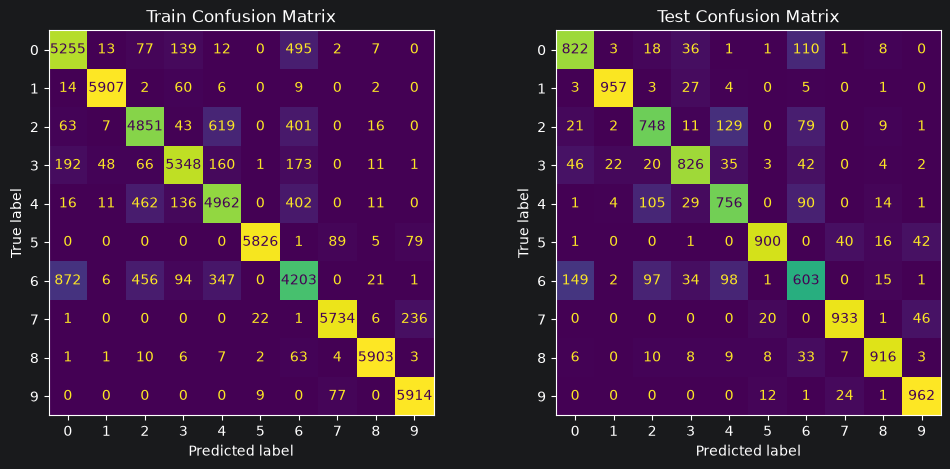

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 1️⃣ Train Confusion Matrix ---
plt.sca(axes[0])
ConfusionMatrixDisplay(confusion_matrix(y_train,MLP.predict(X_train_Reshaped_normalized))).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train Confusion Matrix")

# --- 2️⃣ Test Confusion Matrix ---
plt.sca(axes[1])
ConfusionMatrixDisplay(confusion_matrix(y_test,MLP.predict(X_test_Reshaped_Normalized))).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test Confusion Matrix")

🏁 As expected, the two-layer perceptron outperforms the PCA + Logistic Regression approach. 🎯

*   This happens because **the hidden layer perceptron** acts as a **non-linear feature transformer.**
*   During training, the model **learns and optimizes** the transformation weights to create the most effective feature representation — which ultimately leads to **better classification performance.** 🚀



###🪜 Step 4.3 — Extracting Features from the First Layer

Accessing **MLP.coefs_[0]** and **MLP.intercepts_[0]** allows us to retrieve the **weights and biases** of the hidden layer.
*   The **input dimension** of this layer is **784**, corresponding to the original features (pixels).
*   The **output dimension is 9**, representing the **transformed features** learned by the hidden layer.

Now, complete the following code block to compute **the output of the hidden layer** (i.e., the transformed features).

💡 As a quick reminder:
*   np.matmul(x, y) → performs matrix multiplication of arrays x and y.
*   np.maximum(x, 0) → applies the ReLU activation function on all elements of array x.

In [35]:
c0 = MLP.coefs_[0]
i0 = MLP.intercepts_[0]
X_train_Reshaped_normalized_Transformed=np.maximum(np.matmul(X_train_Reshaped_normalized,c0)+i0,0)
X_test_Reshaped_normalized_Transformed=np.maximum(np.matmul(X_test_Reshaped_Normalized,c0)+i0,0)



If your code is correct, running the following two lines should both return True ✅

In [36]:
isinstance(X_train_Reshaped_normalized_Transformed, np.ndarray) and isinstance(X_test_Reshaped_normalized_Transformed, np.ndarray)

True

In [37]:
X_train_Reshaped_normalized_Transformed.shape==(60000,n_components) and X_test_Reshaped_normalized_Transformed.shape==(10000,n_components)

True

###🪜 Step 4.4 — Logistic Regression

In this step, we’ll train a **Logistic Regression** model using the **transformed features** obtained from the hidden layer of the two-layer perceptron. The goal is to see whether this approach yields better results than **the PCA + Logistic Regression (PCA+LGR)** method.

Set the model parameters exactly **as you did in Step 3.2**.

*💡 Remember: the maximum number of iterations (max_iter) must be less than or equal to 100.*

In [38]:
from sklearn.linear_model import LogisticRegression

LGR2=LogisticRegression(max_iter=LGR.max_iter, C=LGR.C,tol=LGR.tol, solver=LGR.solver)#enter model parameters inside the parenthesis

#Do not change the line below
LGR2.fit(X_train_Reshaped_normalized_Transformed,y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2.0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'newton-cholesky'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. so

▶️ Run the following code to view the classification report and confusion matrix for both the training and testing sets.

In [39]:
from sklearn.metrics  import classification_report,confusion_matrix,ConfusionMatrixDisplay

print("---------Training subset---------\n",classification_report(y_train,LGR2.predict(X_train_Reshaped_normalized_Transformed)))
print("---------Testing subset----------\n",classification_report(y_test,LGR2.predict(X_test_Reshaped_normalized_Transformed)))

---------Training subset---------
               precision    recall  f1-score   support

           0       0.84      0.86      0.85      6000
           1       0.99      0.98      0.99      6000
           2       0.82      0.81      0.82      6000
           3       0.90      0.91      0.91      6000
           4       0.81      0.83      0.82      6000
           5       0.99      0.99      0.99      6000
           6       0.74      0.71      0.73      6000
           7       0.97      0.97      0.97      6000
           8       0.99      0.98      0.99      6000
           9       0.98      0.97      0.97      6000

    accuracy                           0.90     60000
   macro avg       0.90      0.90      0.90     60000
weighted avg       0.90      0.90      0.90     60000

---------Testing subset----------
               precision    recall  f1-score   support

           0       0.80      0.79      0.79      1000
           1       0.97      0.96      0.96      1000
        

Text(0.5, 1.0, 'Test Confusion Matrix')

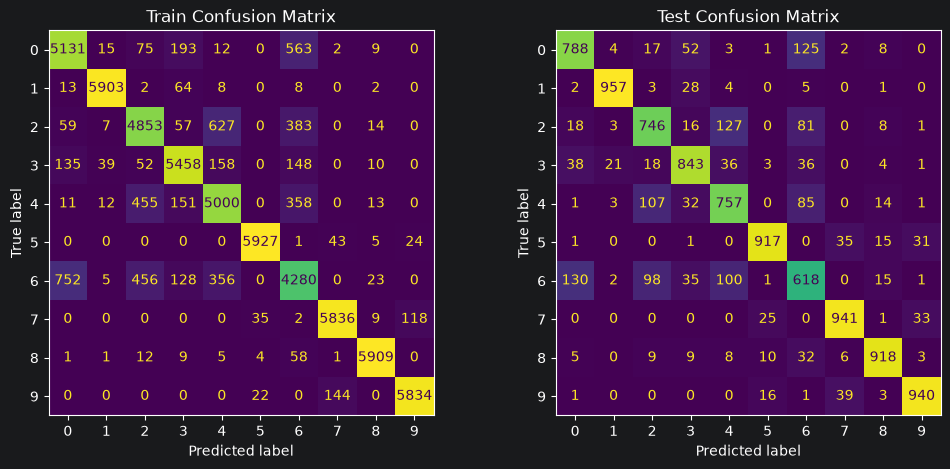

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- 1️⃣ Train Confusion Matrix ---
plt.sca(axes[0])
ConfusionMatrixDisplay(confusion_matrix(y_train,LGR2.predict(X_train_Reshaped_normalized_Transformed))).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Train Confusion Matrix")

# --- 2️⃣ Test Confusion Matrix ---
plt.sca(axes[1])
ConfusionMatrixDisplay(confusion_matrix(y_test,LGR2.predict(X_test_Reshaped_normalized_Transformed))).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Test Confusion Matrix")

## 🔚 Final Remarks — Wrapping It All Up! 🎓

**Important! 🚨**

In this notebook, we explored **three powerful pipelines** for transforming and classifying features:
1.   **🧩 Pipeline 1:** Feature transformation using PCA, followed by a Linear Classifier (Logistic Regression).
2.	**⚙️ Pipeline 2:** A two-layer Perceptron, where the first layer performs feature transformation and the second layer classifies.
3.	**🔁 Pipeline 3:** Feature transformation using a Hidden Layer Perceptron, followed by a Linear Classifier (Logistic Regression).

✨ The key takeaway:
**The two-layer perceptron** — where the first layer transforms features and the second layer classifies — should achieve **higher accuracy** on the test dataset than the PCA + Logistic Regression pipeline.

This demonstrates that the first layer of the neural network performs a more powerful, non-linear feature transformation than PCA.

Finally, by applying **Logistic Regression** on the **transformed features** from the hidden layer of the MLP and achieving a **similar performance**, we confirmed that the improvement truly comes from the **feature transformation** learned by the neural network itself. 💡
